# Polyphase systems

Three-phase power became dominant because it achieves nearly all of the benefits of a multiphase system while keeping wiring, generators, transformers, motors, and transmission networks relatively simple and economical. Higher phase counts offer only incremental improvements for substantially greater complexity.

The 3-phases are displaced 120 degrees apart, and theire vectorial sum is zero:

$$1\angle0+1\angle -120+1\angle120 = 0$$

An eleoctromotive force (emf) is produced by a rotor rotating in a magnetic field.

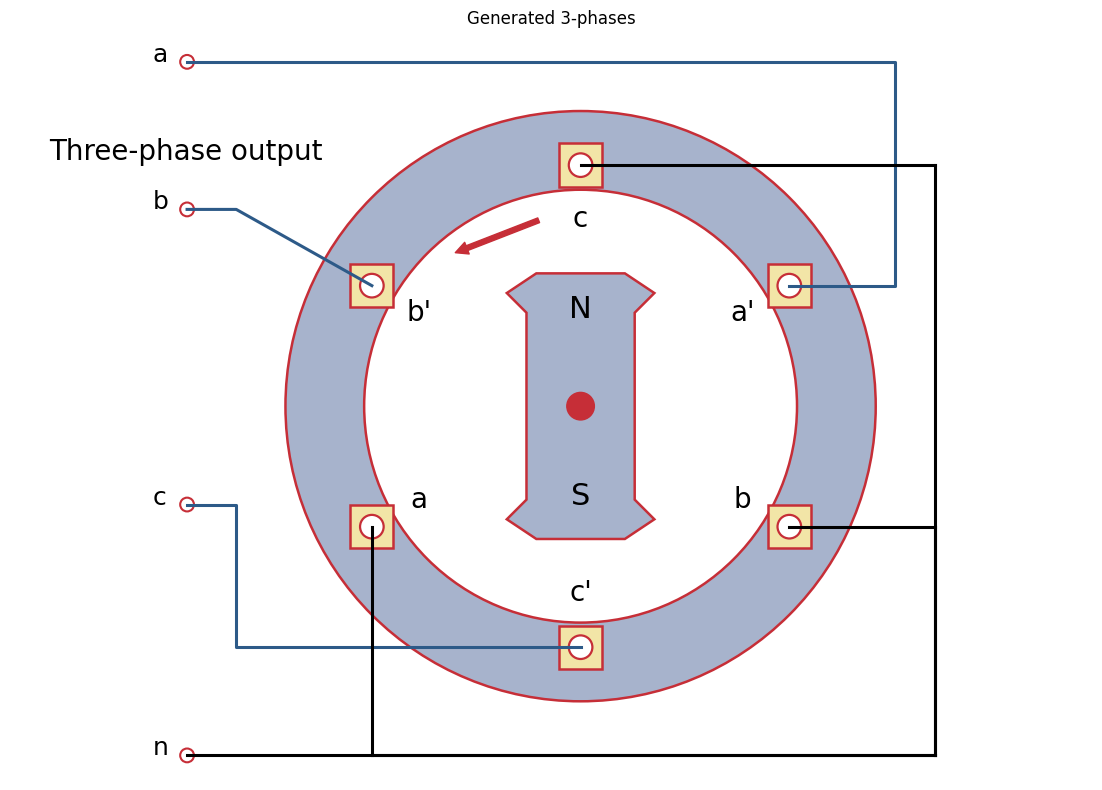

In [1]:
# TEST CELL
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon, Rectangle, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12,8))
ax.set_aspect('equal')
ax.axis('off')

BLUE='#2d5a88'
RED='#c62e37'
STATOR='#a7b3cc'
COIL='#f2e5a7'

ax.add_patch(Circle((0,0),3.0,facecolor=STATOR,edgecolor=RED,lw=1.8))
ax.add_patch(Circle((0,0),2.2,facecolor='white',edgecolor=RED,lw=1.8))

rotor=np.array([[-0.45,1.35],[-0.75,1.15],[-0.55,0.95],[-0.55,-0.95],[-0.75,-1.15],[-0.45,-1.35],[0.45,-1.35],[0.75,-1.15],[0.55,-0.95],[0.55,0.95],[0.75,1.15],[0.45,1.35]])
ax.add_patch(Polygon(rotor,closed=True,facecolor=STATOR,edgecolor=RED,lw=1.8))
ax.add_patch(Circle((0,0),0.14,color=RED))
ax.text(0,0.9,'N',ha='center',fontsize=22)
ax.text(0,-1.0,'S',ha='center',fontsize=22)
ax.add_patch(FancyArrowPatch((-0.4,1.9),(-1.3,1.55),arrowstyle='simple',mutation_scale=18,color=RED))

angles=[90,30,-30,-90,-150,150]
labels=['c',"a'",'b',"c'",'a',"b'"]
coilpos={}
for ang,label in zip(angles,labels):
    t=np.radians(ang)
    x=2.45*np.cos(t); y=2.45*np.sin(t)
    coilpos[label]=(x,y)
    ax.add_patch(Rectangle((x-0.22,y-0.22),0.44,0.44,facecolor=COIL,edgecolor=RED,lw=1.8))
    ax.add_patch(Circle((x,y),0.12,facecolor='white',edgecolor=RED,lw=1.6))
    ax.text(1.9*np.cos(t),1.9*np.sin(t),label,fontsize=20,ha='center',va='center')

terms={'a':(-4,3.5),'b':(-4,2),'c':(-4,-1),'n':(-4,-3.55)}
for k,(x,y) in terms.items():
    ax.add_patch(Circle((x,y),0.07,facecolor='white',edgecolor=RED,lw=1.5))
    ax.text(x-0.35,y,k,fontsize=18)

# External terminals connect to a', b', c'
x,y=coilpos["a'"]
ax.plot([-4,3.2,3.2,x],[3.5,3.5,y,y],color=BLUE,lw=2.2)

x,y=coilpos["b'"]
ax.plot([-4,-3.5,x],[2,2,y],color=BLUE,lw=2.2)

x,y=coilpos["c'"]
ax.plot([-4,-3.5,-3.5,x],[-1,-1,y,y],color=BLUE,lw=2.2)

# Star point: a, b, c joined to n

star = (3.6, -3.55)

# neutral bus
ax.plot([-4, star[0]],
        [-3.55, -3.55],
        color='black',
        lw=2.2)

# a: vertical drop directly to neutral bus
x, y = coilpos['a']

ax.plot([x, x],
        [y, star[1]],
        color='black',
        lw=2.2)

ax.plot([x, star[0]],
        [star[1], star[1]],
        color='black',
        lw=2.2)

# b and c: original routing
for lbl in ['b', 'c']:

    x, y = coilpos[lbl]

    ax.plot([x, star[0]],
            [y, y],
            color='black',
            lw=2.2)

    ax.plot([star[0], star[0]],
            [y, star[1]],
            color='black',
            lw=2.2)


ax.text(-5.4,2.5,'Three-phase output',fontsize=20)
ax.set_xlim(-5.8,5.2)
ax.set_ylim(-3.8,3.8)
ax.set_title('Generated 3-phases')
plt.tight_layout()
#plt.savefig('three_phase_machine_star_reversed.png',dpi=300)
plt.show()


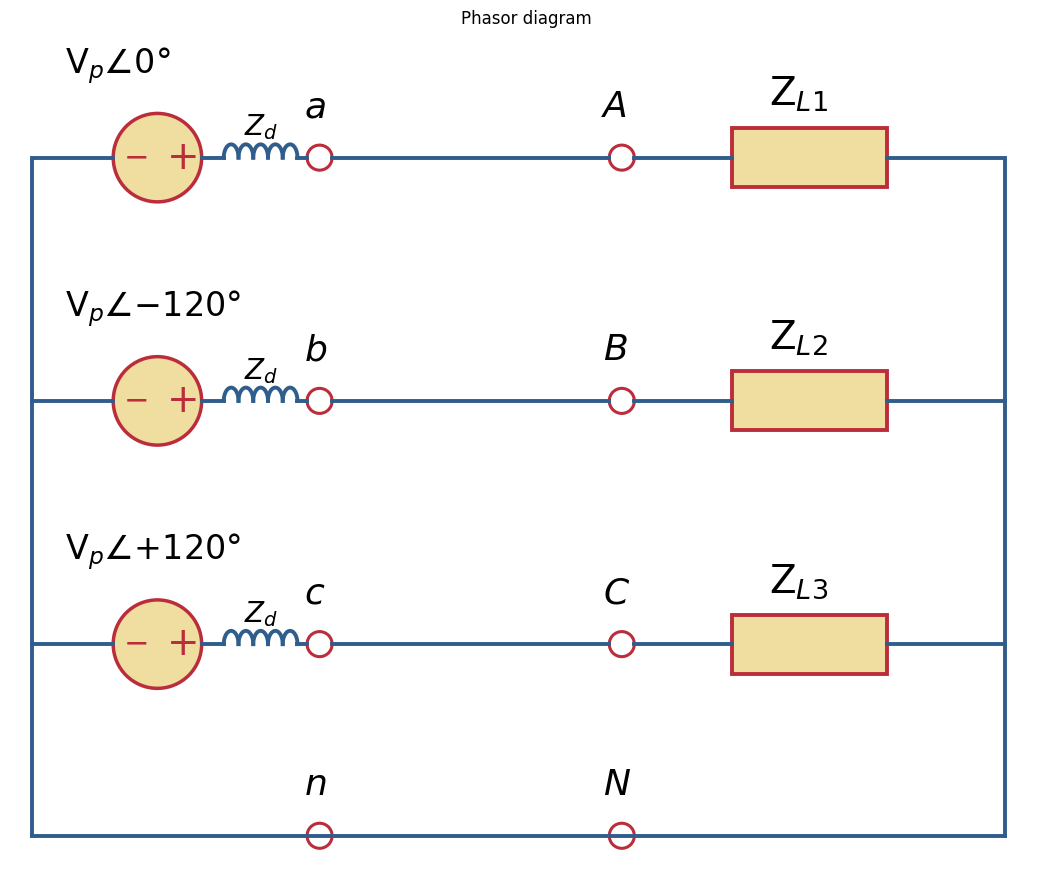

In [2]:
# TEST CELL
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle


def draw_coil(ax, x0, x1, y, loops=5, height=0.18,
              color='#2f5d8c', lw=2.8):
    pitch = (x1 - x0) / loops
    for i in range(loops):
        theta = np.linspace(np.pi, 0, 40)
        xc = x0 + (i + 0.5) * pitch
        x = xc + (pitch / 2) * np.cos(theta)
        ycoil = y + height * np.sin(theta)
        ax.plot(x, ycoil, color=color, lw=lw)

fig, ax = plt.subplots(figsize=(11,9))
ax.set_xlim(0, 14)
ax.set_ylim(0, 11.5)
ax.set_aspect('equal')
ax.axis('off')

wire = '#2f5d8c'
comp = '#bb2d3b'
fill = '#efdea0'

TOP = 9.75
ax.plot([0.3,13.5],[0.6,0.6],color=wire,lw=2.8)
ax.plot([0.3,0.3],[0.6,TOP],color=wire,lw=2.8)
ax.plot([13.5,13.5],[0.6,TOP],color=wire,lw=2.8)

ys=[9.8,6.5,3.2]
phase_labels=['0°','−120°','+120°']
small_left=['a','b','c']
small_right=['A','B','C']
loads=['Z$_{L1}$','Z$_{L2}$','Z$_{L3}$']

for i,y in enumerate(ys):
    ax.plot([0.3, 1.4], [y, y], color=wire, lw=2.8)
    ax.plot([2.6, 2.9], [y, y], color=wire, lw=2.8)

    ax.add_patch(Circle((2.0,y),0.6,facecolor=fill,edgecolor=comp,lw=2.5))
    ax.text(1.72,y,'−',ha='center',va='center',fontsize=22,color=comp)
    ax.text(2.35,y,'+',ha='center',va='center',fontsize=28,color=comp)

    ax.text(0.75,y+1.15,'V$_p$∠'+phase_labels[i],fontsize=24)

    draw_coil(ax, 2.9, 3.9, y, loops=5, height=0.18, color=wire, lw=2.8)

    # Z_d label above coil
    ax.text(3.4, y+0.30, r'$Z_d$', fontsize=20, ha='center')

    ax.plot([3.9, 4.03], [y, y], color=wire, lw=2.8)
    ax.plot([4.37, 8.13], [y, y], color=wire, lw=2.8)
    ax.plot([8.47, 9.8], [y, y], color=wire, lw=2.8)
    ax.plot([11.9, 13.5], [y, y], color=wire, lw=2.8)

    for x in [4.2,8.3]:
        ax.add_patch(Circle((x,y),0.17,facecolor='white',edgecolor=comp,lw=2.2))

    ax.text(4.0,y+0.55,small_left[i],fontsize=26,style='italic')
    ax.text(8.05,y+0.55,small_right[i],fontsize=26,style='italic')

    ax.add_patch(Rectangle((9.8,y-0.4),2.1,0.8,facecolor=fill,edgecolor=comp,lw=2.8))
    ax.text(10.3,y+0.7,loads[i],fontsize=28)

for x in [4.2,8.3]:
    ax.add_patch(Circle((x,0.6),0.17,facecolor='white',edgecolor=comp,lw=2.2))

ax.text(4.0,1.15,'n',fontsize=26,style='italic')
ax.text(8.05,1.15,'N',fontsize=26,style='italic')

ax.set_title('Phasor diagram')

plt.tight_layout()
plt.savefig('three_phase_load_with_coils_Zd.png',dpi=300,bbox_inches='tight')
plt.show()


# $\alpha$-operator

$$ \alpha = e^{j\frac{2\pi}{3}} = -\frac{1}{2}+j \frac{\sqrt{3}}{2} $$

| Operator       | Rectangular Form               | Polar Form           | Angle          |
| -------------- | ------------------------------ | -------------------- | -------------- |
| $1=\alpha^0$   | $1+j0$                      | $1\angle0^\circ$   | $0^\circ$    |
| $\alpha$       | $-\frac12+j\frac{\sqrt3}{2}$ | $1\angle120^\circ$ | $120^\circ$  |
| $\alpha^2$    | $-\frac12-j\frac{\sqrt3}{2}$ | $1\angle240^\circ$ | $-120^\circ$ |
| $\alpha^3$    | $1$                         | $1\angle360^\circ$ | $0^\circ$    |
| $\alpha^4$    | $\alpha$                     | $1\angle120^\circ$ | $120^\circ$  |
| $\alpha^5$    | $\alpha^2$                   | $1\angle240^\circ$ | $-120^\circ$ |


## Fundamental identities

| Identity              | Result       |
| --------------------- | ------------ |
| $\alpha^3$          | $1$       |
| $\alpha^{-1}$       | $\alpha^2$ |
| $\alpha^{-2}$       | $\alpha$   |
| $1+\alpha+\alpha^2$ | $0$        |
| $\alpha\alpha^2$    | $1$        |
| $\alpha+\alpha^2$   | $-1$       |




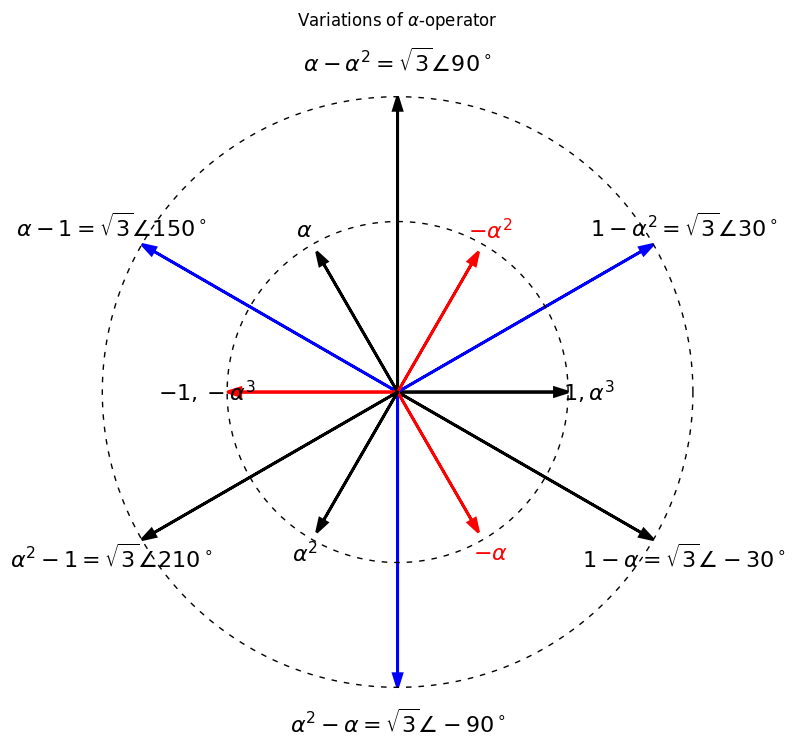

In [17]:
# TEST CELL
import numpy as np
import matplotlib.pyplot as plt

# Constants
R_outer = np.sqrt(3)
R_inner = 1.0

fig, ax = plt.subplots(figsize=(8, 8))

# Draw dashed circles
theta = np.linspace(0, 2*np.pi, 1000)
ax.plot(R_outer*np.cos(theta), R_outer*np.sin(theta),
        'k--', lw=1, dashes=(4, 5))
ax.plot(R_inner*np.cos(theta), R_inner*np.sin(theta),
        'k--', lw=1, dashes=(4, 5))

# Vectors: (angle in degrees, radius, label)
vectors = [
    (0,    R_inner,  r'$1,\alpha^3$',                         'black'),
    (30,   R_outer,  r'$1-\alpha^2=\sqrt{3}\angle 30^\circ$', 'blue'),
    (90,   R_outer,  r'$\alpha-\alpha^2=\sqrt{3}\angle 90^\circ$', 'black'),
    (150,  R_outer,  r'$\alpha-1=\sqrt{3}\angle 150^\circ$', 'blue'),
    (180,  R_inner,  r'$-1,-\alpha^3$',                      'red'),
    (210,  R_outer,  r'$\alpha^2-1=\sqrt{3}\angle 210^\circ$', 'black'),
    (270,  R_outer,  r'$\alpha^2-\alpha=\sqrt{3}\angle -90^\circ$', 'blue'),
    (-30,  R_outer,  r'$1-\alpha=\sqrt{3}\angle -30^\circ$', 'black'),
]

for angle_deg, radius, label, color in vectors:
    angle = np.deg2rad(angle_deg)
    x = radius * np.cos(angle)
    y = radius * np.sin(angle)

    ax.arrow(
        0, 0, x, y,
        length_includes_head=True,
        head_width=0.05,
        head_length=0.08,
        fc=color, ec=color, lw=2
    )

    ax.text(
        1.12*x, 1.12*y, label,
        fontsize=16,
        #color=color,
        ha='center', va='center'
    )

inner_labels = [
    (120, r'$\alpha$', 'black'),
    (60,  r'$-\alpha^2$', 'red'),
    (-60, r'$-\alpha$', 'red'),
    (-120, r'$\alpha^2$', 'black')
]

for angle_deg, label, color in inner_labels:
    angle = np.deg2rad(angle_deg)
    x = 0.95*np.cos(angle)
    y = 0.95*np.sin(angle)

    ax.arrow(
        0, 0, x, y,
        length_includes_head=True,
        head_width=0.05,
        head_length=0.08,
        fc=color, ec=color, lw=2
    )

    ax.text(
        1.15*x, 1.15*y, label,
        fontsize=16,
        color=color,
        ha='center', va='center'
    )

ax.set_aspect('equal')
ax.axis('off')
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2.1)
ax.set_title(r'Variations of $\alpha$-operator')

plt.tight_layout()
plt.show()


## Line - to - line voltage operators

| Expression          | Simplified Form                | Polar Form                 |
| ------------------- | ------------------------------ | -------------------------- |
| $1-\alpha$        | $\sqrt3\,\angle(-30^\circ)$  | $\sqrt3 e^{-j30^\circ}$  |
| $1-\alpha^2$      | $\sqrt3\,\angle(30^\circ)$   | $\sqrt3 e^{j30^\circ}$   |
| $\alpha-\alpha^2$ | $\sqrt3\,\angle(90^\circ)$   | $\sqrt3 e^{j90^\circ}$   |
| $\alpha-1$        | $\sqrt3\,\angle(150^\circ)$  | $\sqrt3 e^{j150^\circ}$  |
| $\alpha^2-1$      | $\sqrt3\,\angle(-150^\circ)$ | $\sqrt3 e^{-j150^\circ}$ |
| $\alpha^2-\alpha$ | $\sqrt3\,\angle(-90^\circ)$  | $\sqrt3 e^{-j90^\circ}$  |

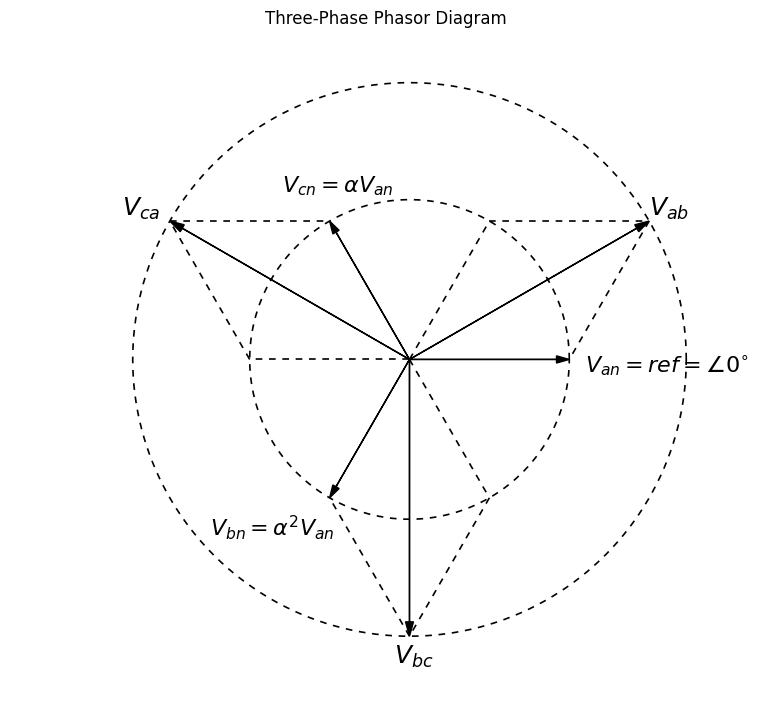

In [4]:
# TEST CELL
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))

R = 1.0
R_LL = np.sqrt(3)

theta = np.linspace(0, 2*np.pi, 1000)
ax.plot(R*np.cos(theta), R*np.sin(theta), 'k--', lw=1.2, dashes=(4, 4))
ax.plot(R_LL*np.cos(theta), R_LL*np.sin(theta), 'k--', lw=1.2, dashes=(4, 4))

for ang in [0, 120, -120]:
    a = np.deg2rad(ang)
    ax.arrow(0, 0, R*np.cos(a), R*np.sin(a),
             length_includes_head=True,
             head_width=0.045,
             head_length=0.08,
             color='k')

for ang in [30, -90, 150]:
    a = np.deg2rad(ang)
    ax.arrow(0, 0, R_LL*np.cos(a), R_LL*np.sin(a),
             length_includes_head=True,
             head_width=0.05,
             head_length=0.09,
             color='k')

p1 = np.array([R_LL*np.cos(np.deg2rad(30)), R_LL*np.sin(np.deg2rad(30))])
p2 = np.array([R_LL*np.cos(np.deg2rad(-90)), R_LL*np.sin(np.deg2rad(-90))])
p3 = np.array([R_LL*np.cos(np.deg2rad(150)), R_LL*np.sin(np.deg2rad(150))])

def draw_truncated_line(ax, A, B, r):
    d = B - A
    aa = np.dot(d, d)
    bb = 2*np.dot(A, d)
    cc = np.dot(A, A) - r**2
    disc = bb**2 - 4*aa*cc

    if disc <= 0:
        ax.plot([A[0], B[0]], [A[1], B[1]], 'k--', lw=1.2, dashes=(4, 4))
        return

    t1 = (-bb - np.sqrt(disc)) / (2*aa)
    t2 = (-bb + np.sqrt(disc)) / (2*aa)

    P1 = A + t1*d
    P2 = A + t2*d

    ax.plot([A[0], P1[0]], [A[1], P1[1]], 'k--', lw=1.2, dashes=(4, 4))
    ax.plot([P2[0], B[0]], [P2[1], B[1]], 'k--', lw=1.2, dashes=(4, 4))

for A, B in [(p1, p2), (p2, p3), (p3, p1)]:
    draw_truncated_line(ax, A, B, R)

for ang in [180, 60, -60]:
    a = np.deg2rad(ang)
    ax.plot([0, R*np.cos(a)], [0, R*np.sin(a)], 'k--', lw=1.2, dashes=(4, 4))

ax.text(1.1, -0.08, r'$V_{an}=ref=\angle0^{\circ}$', fontsize=16)
ax.text(-0.8, 1.05, r'$V_{cn}=\alpha V_{an}$', fontsize=16)
ax.text(-1.25, -1.1, r'$V_{bn}=\alpha^2V_{an}$', fontsize=16)

ax.text(1.5, 0.90, r'$V_{ab}$', fontsize=18)
ax.text(-0.1, -1.9, r'$V_{bc}$', fontsize=18)
ax.text(-1.8, 0.90, r'$V_{ca}$', fontsize=18)

ax.set_aspect('equal')
ax.axis('off')
ax.set_xlim(-2.5, 2.2)
ax.set_ylim(-2.15, 2.05)
ax.set_title('Three-Phase Phasor Diagram')

plt.tight_layout()
plt.show()


### EXAMPLE 2.3

In a balanced three-phase circuit, the voltage Vab is $173.2\angle 0^{\circ}$ V. Determine all
the voltages and the currents in a Y-connected load having $Z_L= 10\angle 20^{\circ}\Omega$.
Assume that the phase sequence is *abc*.

Balanced Three-Phase Y-Connected Load Solution

Given:
Vab = 173.2∠0° V
ZL = 10∠20° Ω
Phase sequence = abc

Phase Voltages:
Van = 100∠-30° V
Vbn = 100∠-150° V
Vcn = 100∠90° V

Line Voltages:
Vab = 173.2∠0° V
Vbc = 173.2∠-120° V
Vca = 173.2∠120° V

Phase/Line Currents:
Ia = Ian = 10∠-50° A
Ib = Ibn = 10∠-170° A
Ic = Icn = 10∠70° A

Python Script:

Phase Voltages:
Van = 100.00 ∠ -30.00° V
Vbn = 100.00 ∠ -150.00° V
Vcn = 100.00 ∠ 90.00° V

Line Voltages:
Vab = 173.20 ∠ 0.00° V
Vbc = 173.20 ∠ -120.00° V
Vca = 173.20 ∠ 120.00° V

Line/Phase Currents:
Ian = 10.00 ∠ -50.00° A
Ibn = 10.00 ∠ -170.00° A
Icn = 10.00 ∠ 70.00° A


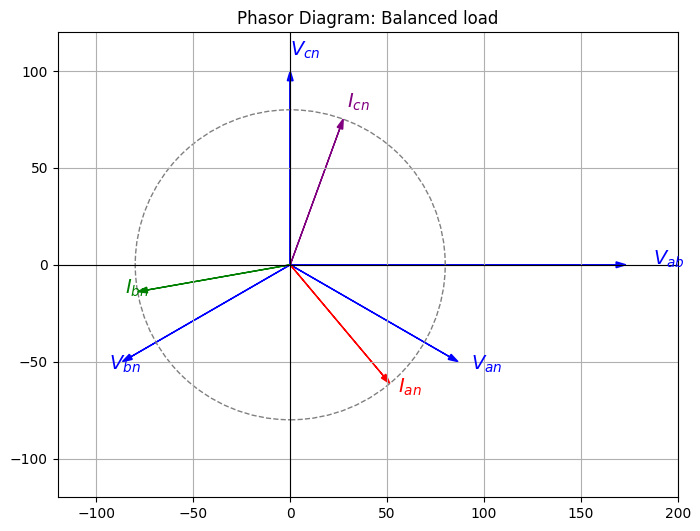

In [61]:
# TEST CELL
import cmath
import math
import matplotlib.pyplot as plt

# Given data
Vab_mag = 173.2
Vab_ang = 0
ZL_mag = 10
ZL_ang = 20

# Convert to complex phasors
Vab = cmath.rect(Vab_mag, math.radians(Vab_ang))
ZL = cmath.rect(ZL_mag, math.radians(ZL_ang))

# Phase voltages
Van = (Vab_mag / math.sqrt(3)) * cmath.exp(1j * math.radians(-30))
Vbn = (Vab_mag / math.sqrt(3)) * cmath.exp(1j * math.radians(210))
Vcn = (Vab_mag / math.sqrt(3)) * cmath.exp(1j * math.radians(90))

Vab = Van - Vbn


# Currents
Ian = Van / ZL
Ibn = Vbn / ZL
Icn = Vcn / ZL

Iab = Ian - Ibn

# Line voltages
Vbc = Vab_mag * cmath.exp(1j * math.radians(-120))
Vca = Vab_mag * cmath.exp(1j * math.radians(120))

def polar(z):
    return abs(z), math.degrees(cmath.phase(z))

print('Phase Voltages:')
for name, val in [('Van', Van), ('Vbn', Vbn), ('Vcn', Vcn)]:
    mag, ang = polar(val)
    print(f'{name} = {mag:.2f} ∠ {ang:.2f}° V')

print('\nLine Voltages:')
for name, val in [('Vab', Vab), ('Vbc', Vbc), ('Vca', Vca)]:
    mag, ang = polar(val)
    print(f'{name} = {mag:.2f} ∠ {ang:.2f}° V')

print('\nLine/Phase Currents:')
for name, val in [('Ian', Ian), ('Ibn', Ibn), ('Icn', Icn)]:
    mag, ang = polar(val)
    print(f'{name} = {mag:.2f} ∠ {ang:.2f}° A')
#phasors
fig, ax = plt.subplots(figsize=(8, 8))

def draw_phasor(z, label, color='black', scale=1):
    ax.arrow(
        0, 0,
        z.real * scale,
        z.imag * scale,
        head_width=3,
        head_length=5,
        length_includes_head=True,
        color=color
    )

    ax.text(
        z.real * scale * 1.08,
        z.imag * scale * 1.08,
        label,
        fontsize=14,
        color=color
    )

current_scale = 8

draw_phasor(Van, r'$V_{an}$', 'blue')
draw_phasor(Vbn, r'$V_{bn}$', 'blue')
draw_phasor(Vcn, r'$V_{cn}$', 'blue')
draw_phasor(Vab, r'$V_{ab}$', 'blue')
draw_phasor(Ian, r'$I_{an}$', 'red', current_scale)
draw_phasor(Ibn, r'$I_{bn}$', 'green', current_scale)
draw_phasor(Icn, r'$I_{cn}$', 'purple', current_scale)
#draw_phasor(Iab, r'$I_{ab}$', 'black', current_scale)
circle = plt.Circle((0, 0), 80, fill=False, linestyle='--', color='gray')
ax.add_artist(circle)

ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)

ax.set_aspect('equal')
ax.grid(True)
ax.set_title('Phasor Diagram: Balanced load')
ax.set_xlim(-120, 200)
ax.set_ylim(-120, 120)

plt.show()

## Control

Checking the sum of balanced systems 

In [60]:
print('Sum of line-to-neutral voltages',np.round(Van + Vbn + Vcn))
print('Sum of line-to-line voltages',np.round(Vab + Vbc + Vca))
print('Sum of line currents',np.round(Ian + Ibn + Icn))

Sum of line-to-neutral voltages 0j
Sum of line-to-line voltages 0j
Sum of line currents 0j
